# Bayesian Hypothesis Elimination in Transformer Attention

## Overview

This notebook contains the computational experiments for the project
**"The Training-Bound Emergence of Bayesian Hypothesis Elimination in Transformer
Attention: An Information-Theoretic and Geometric Study in Bijection Wind Tunnels"**.

The goal is to reproduce and extend the Bayesian bijection-elimination wind tunnel
introduced by Agarwal et al. [1], and to investigate whether the Bayesian behaviour
learned by a Transformer generalizes beyond the structures encountered during
training.

The task is deliberately constructed so that the exact Bayesian posterior
predictive distribution is known analytically. A hidden bijection
$\pi: \mathcal{V}\to\mathcal{V}$ generates input-output pairs

$$
y_i = \pi(x_i)
$$

and the model must predict the output associated with a query $x$.

For a **novel query**, Bayesian inference assigns equal probability to all outputs
that have not yet been observed. For a **repeated query**, the posterior predictive
distribution is deterministic, since the corresponding mapping has already been
identified.

This makes the task a controlled "wind tunnel" in which the model's predictions
can be compared directly with the exact Bayesian solution.

We train four models, varying both the query horizon and the presence of repetitions during training:

| Model | $K$ | $p_{\mathrm{repeat,train}}$ |
|---|---:|---:|
| A | $1.5V$ | 0.3 |
| B | $1.5V$ | 0 |
| C | $V-1$ | 0.3 |
| D | $V-1$ | 0 |

In this notebook we focus on the training and evaluation of the Models C and D. It is easy to change the parameters and to train and evaluate models A and B.

**AI Usage**: This code was carried out in accordance with the Physics of Data AI policies. Specifically,
Generative AI tools (including Claude model Sonnet 5 and Gemini) were utilized to assist in
developing sections of the Python code, particularly concerning the adaptation of minGPT.

## Setup

Clone and install minGPT, then check that a GPU is available. Everything below assumes a CUDA device
(T4 on Kaggle).

In [ ]:
import os
import sys
import subprocess

print("Initializing minGPT setup...")

repo_dir = "minGPT"

try:
    if not os.path.exists(repo_dir):
        print("Cloning from GitHub...")
        subprocess.check_call(["git", "clone", "https://github.com/karpathy/minGPT.git"])
    
    print("Installing via pip...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", f"./{repo_dir}", "-q"])
    
    repo_path = os.path.abspath(repo_dir)
    if repo_path not in sys.path:
        sys.path.append(repo_path)
    
    print("Setup completed successfully!")

except subprocess.CalledProcessError as e:
    raise RuntimeError(
        "\n"
        "========================================================================\n"
        "CRITICAL ERROR: Failed to clone/install minGPT. \n"
        "========================================================================"
    ) from e

Initializing minGPT setup...
Cloning from GitHub...


Cloning into 'minGPT'...


Installing via pip...
Setup completed successfully!


In [ ]:
import glob
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from mingpt.model import GPT
from mingpt.trainer import Trainer

torch.backends.cudnn.benchmark = True

print("CUDA available:", torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected.")

CUDA available: True
Device: Tesla T4


## Task configuration

Here we set the vocabulary dimension $V$ and the query horizon $K$.

In [3]:
V = 20
SEP_ID = V
VOCAB_SIZE = V + 1
K_QUERIES = V - 1 
BLOCK_SIZE = 3 * K_QUERIES - 1

print(f"V={V}, K_QUERIES={K_QUERIES}, vocab_size={VOCAB_SIZE}, block_size={BLOCK_SIZE}")

V=20, K_QUERIES=19, vocab_size=21, block_size=56


## Data generation and loss masking

Each sequence is `[x_1, y_1, SEP, ..., x_K, y_K, SEP]`. At each step we either
query a new input, or repeat
one already queried. The loss is masked to only the `y_k` positions, so that the model is never trained to
predict SEP tokens or the next query input.

In [ ]:
def make_bijection_sequence(V, K, p_repeat=0.3, rng=random):
    """
    Generates a random bijection and constructs a sequence of K queries.

    The sequence randomly mixes novel inputs with repeated queries based on `p_repeat`. 
    If all V possible inputs have already been queried, all subsequent steps are forced 
    to be repeats.

    Returns:
        seq (list[int]): A flattened sequence formatted as [x_1, y_1, SEP, ..., x_K, y_K, SEP].
        meta (list[dict]): Metadata for each query step, containing the keys 'x' (input), 
                           'y' (output), 'is_repeat' (boolean), and 'n_used_before' (integer).
    """
    pi = list(range(V))
    rng.shuffle(pi)

    used_inputs = []
    used_set = set()
    seq = []
    meta = []

    for _ in range(K):
        n_used_before = len(used_set)
        can_repeat = n_used_before > 0
        force_repeat = (n_used_before == V)

        if force_repeat or (can_repeat and rng.random() < p_repeat):
            x = rng.choice(used_inputs)
            is_repeat = True
        else:
            unused = [i for i in range(V) if i not in used_set]
            x = rng.choice(unused)
            is_repeat = False
            used_inputs.append(x)
            used_set.add(x)

        y = pi[x]
        seq.extend([x, y, SEP_ID])
        meta.append({'x': x, 'y': y, 'is_repeat': is_repeat, 'n_used_before': n_used_before})

    return seq, meta


class BijectionDataset(Dataset):
    """
    An infinite-sample PyTorch Dataset for bijection sequences.

    The `__getitem__` method ignores the provided index and generates a fresh, 
    random bijection sequence on the fly. The `__len__` method returns a nominal 
    epoch length, as the training loop typically relies on `max_iters` rather 
    than strict epoch boundaries.
    """
    def __init__(self, V, K, p_repeat=0.3):
        self.V = V
        self.K = K
        self.p_repeat = p_repeat

    def __len__(self):
        return 100_000  # no real meaning, just a nominal epoch length

    def __getitem__(self, idx):
        seq, _ = make_bijection_sequence(self.V, self.K, self.p_repeat)
        seq = torch.tensor(seq, dtype=torch.long)
        x = seq[:-1].clone()
        y = seq[1:].clone()
        keep = (torch.arange(len(y)) % 3 == 0)
        y[~keep] = -1
        return x, y

## Exact Bayesian posterior (bits)

For a **new** query, entropy = `log2(V - n_used)`; for a **repeat** query,
entropy = 0 exactly (point mass on the previously-revealed output).

In [5]:
def bayes_entropy_bits(V, n_used):
    remaining = V - n_used
    return math.log2(remaining) if remaining > 1 else 0.0

print("Example: bayes_entropy_bits(V=20, n_used=5) =", bayes_entropy_bits(20, 5))

Example: bayes_entropy_bits(V=20, n_used=5) = 3.9068905956085187


## Batched evaluation
This section defines the `evaluate_full_batched` function, which evaluates the model's predictions on a set of held-out bijection sequences.

To maximize GPU efficiency, it processes the sequences in batches. For each step, it compares the model's output against the exact Bayesian posterior, computing metrics such as entropy, forbidden mass, and KL divergence for novel queries, alongside hard accuracy (`repetition_accuracy`) and cross-entropy for repeated queries.

In [ ]:
@torch.no_grad()
def evaluate_full_batched(model, V, K, device, n_seqs=2000, seed=1234, p_repeat=0.3, batch_size=500):
    """
    Generates a specified number of held-out bijection sequences, processes them in batches, 
    and evaluates the model's predictive performance. Running a single forward pass per batch 
    instead of per sequence significantly improves evaluation efficiency.

    Args:
        model (torch.nn.Module): The model to be evaluated.
        V (int): The vocabulary size (number of unique elements in the bijection).
        K (int): The query horizon (number of steps per sequence).
        device (str or torch.device): The device on which to perform computations.
        n_seqs (int, optional): Total number of sequences to evaluate. Defaults to 2000.
        seed (int, optional): Random seed for reproducible sequence generation. Defaults to 1234.
        p_repeat (float, optional): The probability of repeating a previously queried input. Defaults to 0.3.
        batch_size (int, optional): The number of sequences to process in a single batch. Defaults to 500.

    Returns:
        dict: A dictionary containing the calculated evaluation metrics:
            - 'n_new' (int): Number of novel queries evaluated.
            - 'n_repeat' (int): Number of repeated queries evaluated.
            - 'mae_new' (float): Mean Absolute Error between the model's entropy and the exact Bayesian entropy for novel queries.
            - 'mean_forbidden_mass' (float): Average probability mass assigned to already observed (forbidden) outputs during novel queries.
            - 'mean_kl_new' (float): Mean Kullback-Leibler divergence for novel queries.
            - 'mean_prob_true_y_repeat' (float): Average probability the model assigns to the correct output for repeated queries.
            - 'mean_cross_entropy_repeat' (float): Average cross-entropy for repeated queries.
            - 'repetition_accuracy' (float): The hard accuracy (argmax match) for predicting the output of repeated queries.
    """
    model.eval()
    rng = random.Random(seed)

    all_seqs, all_metas = [], []
    for _ in range(n_seqs):
        seq, meta = make_bijection_sequence(V, K, p_repeat, rng=rng)
        all_seqs.append(seq)
        all_metas.append(meta)

    new_H_model, new_H_bayes, new_forbidden_mass, new_kl = [], [], [], []
    repeat_prob_true_y, repeat_cross_entropy, repeat_correct = [], [], []

    for start in range(0, n_seqs, batch_size):
        batch_seqs = all_seqs[start:start + batch_size]
        batch_metas = all_metas[start:start + batch_size]

        x = torch.tensor([s[:-1] for s in batch_seqs], dtype=torch.long, device=device)
        logits, _ = model(x)  # (B, 3K-1, vocab_size)

        probs_all = F.softmax(logits, dim=-1)  # softmax over the FULL vocab (V value tokens + SEP)
        probs_full = probs_all[:, :, :V]  # drop the SEP probability, keep the V value tokens
        probs_full = probs_full / probs_full.sum(dim=-1, keepdim=True)  # renormalize after dropping SEP mass
        probs_np = probs_full.detach().cpu().numpy()  # (B, 3K-1, V)

        for b, meta in enumerate(batch_metas):
            used_before_this_seq = set()
            for i, m in enumerate(meta):
                p_pos = 3 * i  # position of x_i -> predicts y_i, see the masking logic above
                probs = probs_np[b, p_pos]  # (V,)

                if m['is_repeat']:
                    p_true = float(probs[m['y']])
                    repeat_prob_true_y.append(p_true)
                    repeat_cross_entropy.append(-math.log2(max(p_true, 1e-12)))
                    repeat_correct.append(float(int(np.argmax(probs)) == m['y']))
                else:
                    n_used = m['n_used_before']
                    H_bayes = bayes_entropy_bits(V, n_used)
                    H_model = float(-(probs * np.log2(np.clip(probs, 1e-12, None))).sum())
                    new_H_model.append(H_model)
                    new_H_bayes.append(H_bayes)

                    forbidden = float(sum(probs[y_used] for y_used in used_before_this_seq))
                    new_forbidden_mass.append(forbidden)

                    unused = [v for v in range(V) if v not in used_before_this_seq]
                    M = len(unused)
                    kl = -math.log2(M) - (1.0 / M) * sum(
                        math.log2(max(probs[v], 1e-12)) for v in unused
                    )
                    new_kl.append(kl)

                used_before_this_seq.add(m['y'])

    results = {
        'n_new': len(new_H_model),
        'n_repeat': len(repeat_prob_true_y),
        'mae_new': float(np.mean(np.abs(np.array(new_H_model) - np.array(new_H_bayes)))),
        'mean_forbidden_mass': float(np.mean(new_forbidden_mass)),
        'mean_kl_new': float(np.mean(new_kl)),
        'mean_prob_true_y_repeat': float(np.mean(repeat_prob_true_y)) if repeat_prob_true_y else float('nan'),
        'mean_cross_entropy_repeat': float(np.mean(repeat_cross_entropy)) if repeat_cross_entropy else float('nan'),
        'repetition_accuracy': float(np.mean(repeat_correct)) if repeat_correct else float('nan'),
    }
    model.train()
    return results

## Adaptive checkpoint schedule

This section generates a dual-resolution schedule for saving model checkpoints. It applies a fine-grained saving frequency during the initial training phase to capture rapid behavioral transitions, and shifts to a coarse-grained interval for the remainder of the run to optimize computational resources.

In [ ]:
def build_checkpoint_schedule(fine_end=20_000, fine_step=500, coarse_end=150_000, coarse_step=10_000):
    """
    Generates a sorted list of training iterations for saving checkpoints and running evaluations.

    The schedule applies a fine-grained interval for the initial phase of training and 
    transitions to a coarse-grained interval for the remainder.

    Args:
        fine_end (int, optional): The iteration at which the fine-grained schedule ends. Defaults to 20,000.
        fine_step (int, optional): The interval between checkpoints during the fine phase. Defaults to 500.
        coarse_end (int, optional): The final training iteration for the schedule. Defaults to 150,000.
        coarse_step (int, optional): The interval between checkpoints during the coarse phase. Defaults to 10,000.

    Returns:
        list[int]: A sorted list of unique iteration numbers.
    """
    fine = list(range(0, fine_end + 1, fine_step))
    coarse = list(range(fine_end + coarse_step, coarse_end + 1, coarse_step))
    return sorted(set(fine + coarse))

CHECKPOINT_SCHEDULE = build_checkpoint_schedule()
print(f"{len(CHECKPOINT_SCHEDULE)} checkpoints scheduled per model "
      f"({len(CHECKPOINT_SCHEDULE) * 2} total for both models)")
print("First few:", CHECKPOINT_SCHEDULE[:5], "... last few:", CHECKPOINT_SCHEDULE[-5:])

54 checkpoints scheduled per model (108 total for both models)
First few: [0, 500, 1000, 1500, 2000] ... last few: [110000, 120000, 130000, 140000, 150000]


## Training function with resume support

A unified training function used for both Model C and Model D. Key features include:

* **Adaptive Checkpointing:** Evaluates and saves the model only at the iterations defined in `CHECKPOINT_SCHEDULE`.
* **Auto-Resume:** Automatically picks up from the latest saved checkpoint for the given `run_name`.
* **Storage Optimization:** Saves only the `model_state_dict` (excluding optimizer state) to stay within output limits. Resuming resets AdamW's momentum, but the transient impact is negligible due to the constant learning rate.
* **Fast Training Loop:** Performs only a lightweight evaluation during training. The comprehensive evaluation sweep is deferred until a separate post-training pass.

In [ ]:
def find_latest_checkpoint(checkpoint_dir, run_name):
    """
    Locates the most recent model checkpoint for a given run name.

    Args:
        checkpoint_dir (str): The directory containing the saved checkpoints.
        run_name (str): The prefix identifier for the specific training run.

    Returns:
        tuple: A tuple containing the file path of the latest checkpoint (str) 
               and its corresponding iteration number (int). Returns (None, 0) 
               if no checkpoints are found.
    """
    if not os.path.isdir(checkpoint_dir):
        return None, 0
    prefix = f"{run_name}_iter"
    candidates = []
    for fname in os.listdir(checkpoint_dir):
        if fname.startswith(prefix) and fname.endswith(".pt"):
            try:
                it = int(fname[len(prefix):-3])
                candidates.append((it, fname))
            except ValueError:
                continue
    if not candidates:
        return None, 0
    candidates.sort()
    best_iter, best_fname = candidates[-1]
    return os.path.join(checkpoint_dir, best_fname), best_iter


def train_bijection_model_resumable(V, K, p_repeat_train, device,
                                     max_iters=150_001, batch_size=64, learning_rate=1e-3,
                                     n_layer=6, n_head=6, n_embd=192,
                                     checkpoint_schedule=None,
                                     eval_n_seqs=200, eval_p_repeat=None,
                                     checkpoint_dir='/kaggle/working/checkpoints',
                                     run_name='model_C'):
    """
    Trains a Transformer model on the bijection task with checkpoint resuming capabilities.

    This function initializes a new model or resumes training based on the latest 
    available checkpoint in the specified directory. It evaluates the model and saves 
    its state only at the specific iterations listed in `checkpoint_schedule`.

    Args:
        V (int): Vocabulary size.
        K (int): Query horizon (number of steps per sequence).
        p_repeat_train (float): Probability of repeating a query during training.
        device (str or torch.device): Device to run the training on.
        max_iters (int, optional): Maximum number of training iterations. Defaults to 150_001.
        batch_size (int, optional): Training batch size. Defaults to 64.
        learning_rate (float, optional): Optimizer learning rate. Defaults to 1e-3.
        n_layer (int, optional): Number of Transformer layers. Defaults to 6.
        n_head (int, optional): Number of attention heads. Defaults to 6.
        n_embd (int, optional): Embedding dimension. Defaults to 192.
        checkpoint_schedule (list[int], optional): Specific iterations to save and evaluate.
        eval_n_seqs (int, optional): Number of sequences to use for evaluation. Defaults to 200.
        eval_p_repeat (float, optional): Probability of repeating a query during evaluation.
        checkpoint_dir (str, optional): Directory to store checkpoints. Defaults to '/kaggle/working/checkpoints'.
        run_name (str, optional): Identifier for the training run (e.g., 'model_C', 'model_D'). Defaults to 'model_C'.

    Returns:
        tuple: A tuple containing the trained model, a history dictionary of metrics, and the model configuration.
    """
    if checkpoint_schedule is None:
        checkpoint_schedule = CHECKPOINT_SCHEDULE
    if eval_p_repeat is None:
        eval_p_repeat = p_repeat_train
    os.makedirs(checkpoint_dir, exist_ok=True)

    model_config = GPT.get_default_config()
    model_config.model_type = None
    model_config.vocab_size = V + 1
    model_config.block_size = 3 * K - 1
    model_config.n_layer = n_layer
    model_config.n_head = n_head
    model_config.n_embd = n_embd
    model = GPT(model_config)
    model.to(device)

    ckpt_path, start_iter = find_latest_checkpoint(checkpoint_dir, run_name)
    history_path = os.path.join(checkpoint_dir, f"{run_name}_history.json")
    history = {'iter': [], 'loss': [], 'mae_new': [], 'forbidden_mass': [],
               'kl_new': [], 'prob_true_y_repeat': [], 'repetition_accuracy': []}

    if ckpt_path is not None:
        print(f"[{run_name}] resuming from {ckpt_path} (iter {start_iter})")
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state['model_state_dict'])
        if os.path.exists(history_path):
            with open(history_path) as f:
                history = json.load(f)
    else:
        print(f"[{run_name}] no existing checkpoint found -- starting fresh")

    if start_iter >= max_iters:
        print(f"[{run_name}] already trained to iter {start_iter} >= max_iters={max_iters}, nothing to do")
        model.eval()
        return model, history, model_config

    n_params = sum(p.numel() for p in model.parameters())
    print(f"[{run_name}] model parameters: {n_params / 1e6:.2f}M | p_repeat_train={p_repeat_train} | "
          f"resuming at iter {start_iter}, training to {max_iters}")

    train_dataset = BijectionDataset(V, K, p_repeat_train)
    train_config = Trainer.get_default_config()
    train_config.max_iters = max_iters - start_iter  # remaining iterations for THIS session
    train_config.batch_size = batch_size
    train_config.learning_rate = learning_rate
    train_config.num_workers = 0

    trainer = Trainer(train_config, model, train_dataset)

    remaining_schedule = [it for it in checkpoint_schedule if it > start_iter]
    schedule_set = set(remaining_schedule)

    def on_batch_end(trainer):
        global_iter = start_iter + trainer.iter_num
        if trainer.iter_num % 100 == 0:
            print(f"[{run_name}] iter {global_iter:7d} | loss {trainer.loss.item():.4f}")

        if global_iter in schedule_set:
            r = evaluate_full_batched(trainer.model, V, K, device, n_seqs=eval_n_seqs, p_repeat=eval_p_repeat)
            history['iter'].append(global_iter)
            history['loss'].append(trainer.loss.item())
            history['mae_new'].append(r['mae_new'])
            history['forbidden_mass'].append(r['mean_forbidden_mass'])
            history['kl_new'].append(r['mean_kl_new'])
            history['prob_true_y_repeat'].append(r['mean_prob_true_y_repeat'])
            history['repetition_accuracy'].append(r['repetition_accuracy'])
            print(f"  >> [{run_name} eval @ iter {global_iter}] "
                  f"MAE(new)={r['mae_new']:.4f} | forbidden_mass={r['mean_forbidden_mass']:.5f} | "
                  f"KL(new)={r['mean_kl_new']:.4f} | P(true_y|repeat)={r['mean_prob_true_y_repeat']:.4f} | "
                  f"rep_acc={r['repetition_accuracy']:.4f}")

            ckpt_out_path = os.path.join(checkpoint_dir, f"{run_name}_iter{global_iter}.pt")
            torch.save({
                'iter_num': global_iter,
                'model_state_dict': trainer.model.state_dict(),
                'model_config': model_config,
                'V': V, 'K': K, 'p_repeat_train': p_repeat_train,
            }, ckpt_out_path)

            with open(history_path, 'w') as f:
                json.dump(history, f)

    trainer.set_callback('on_batch_end', on_batch_end)
    trainer.run()

    model.eval()
    return model, history, model_config

## Train Models

In [9]:
model_C, history_C, model_config = train_bijection_model_resumable(
    V, K_QUERIES, p_repeat_train=0.3, device=device,
    max_iters=150_000, checkpoint_dir='/kaggle/working/checkpoints', run_name='model_C_p03',
)

number of parameters: 2.68M
[model_C_p03] no existing checkpoint found -- starting fresh
[model_C_p03] model parameters: 2.69M | p_repeat_train=0.3 | resuming at iter 0, training to 150000
running on device cuda
[model_C_p03] iter       0 | loss 3.0809
[model_C_p03] iter     100 | loss 3.0010
[model_C_p03] iter     200 | loss 2.9950
[model_C_p03] iter     300 | loss 2.9740
[model_C_p03] iter     400 | loss 2.9523
[model_C_p03] iter     500 | loss 2.8627
  >> [model_C_p03 eval @ iter 500] MAE(new)=0.6351 | forbidden_mass=0.32048 | KL(new)=0.6391 | P(true_y|repeat)=0.2035 | rep_acc=0.2135
[model_C_p03] iter     600 | loss 2.8571
[model_C_p03] iter     700 | loss 2.8405
[model_C_p03] iter     800 | loss 2.8351
[model_C_p03] iter     900 | loss 2.8009
[model_C_p03] iter    1000 | loss 2.8459
  >> [model_C_p03 eval @ iter 1000] MAE(new)=0.5846 | forbidden_mass=0.25602 | KL(new)=0.4808 | P(true_y|repeat)=0.2149 | rep_acc=0.2006
[model_C_p03] iter    1100 | loss 2.8113
[model_C_p03] iter    1

In [10]:
model_D, history_D, _ = train_bijection_model_resumable(
    V, K_QUERIES, p_repeat_train=0.0, device=device,
    max_iters=150_000, checkpoint_dir='/kaggle/working/checkpoints', run_name='model_D_p00',
)

number of parameters: 2.68M
[model_D_p00] no existing checkpoint found -- starting fresh
[model_D_p00] model parameters: 2.69M | p_repeat_train=0.0 | resuming at iter 0, training to 150000
running on device cuda
[model_D_p00] iter       0 | loss 3.0656
[model_D_p00] iter     100 | loss 2.8626
[model_D_p00] iter     200 | loss 2.6147
[model_D_p00] iter     300 | loss 2.5404
[model_D_p00] iter     400 | loss 2.4693
[model_D_p00] iter     500 | loss 2.4477
  >> [model_D_p00 eval @ iter 500] MAE(new)=0.2673 | forbidden_mass=0.08799 | KL(new)=0.2526 | P(true_y|repeat)=nan | rep_acc=nan
[model_D_p00] iter     600 | loss 2.3995
[model_D_p00] iter     700 | loss 2.3568
[model_D_p00] iter     800 | loss 2.3195
[model_D_p00] iter     900 | loss 2.3298
[model_D_p00] iter    1000 | loss 2.2997
  >> [model_D_p00 eval @ iter 1000] MAE(new)=0.0655 | forbidden_mass=0.01582 | KL(new)=0.0869 | P(true_y|repeat)=nan | rep_acc=nan
[model_D_p00] iter    1100 | loss 2.3104
[model_D_p00] iter    1200 | loss 2

## Deep evaluation sweep over saved checkpoints

For every saved checkpoint of both models, run the full batched evaluation at each `p_repeat_eval` in
`{0, 0.1, ..., 0.6}`, over 2000 held-out bijections. With batching this is cheap enough to do for every
checkpoint rather than a hand-picked subset, and it is the data the training-curve and phase-transition
plots below are built from.

Results are accumulated into **one combined CSV** per model plus one merged CSV, not one file per
checkpoint, to respect Kaggle's 500-file output limit.

In [11]:
def load_model_from_checkpoint(ckpt_path, device):
    state = torch.load(ckpt_path, map_location=device, weights_only=False) 
    model_config = state['model_config']
    model = GPT(model_config)
    model.load_state_dict(state['model_state_dict'])
    model.to(device)
    model.eval()
    return model, state['iter_num'], state['V'], state['K'], state['p_repeat_train']


P_REPEAT_SWEEP = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
EVAL_N_SEQS = 2000

def run_deep_eval_sweep(checkpoint_dir, run_name, device, out_csv):
    rows = []
    ckpts = sorted(
        glob.glob(os.path.join(checkpoint_dir, f"{run_name}_iter*.pt")),
        key=lambda p: int(p.split('iter')[-1].replace('.pt', ''))
    )
    for idx, ckpt_path in enumerate(ckpts):
        model, iter_num, V_ck, K_ck, p_repeat_train = load_model_from_checkpoint(ckpt_path, device)
        for p_repeat_eval in P_REPEAT_SWEEP:
            r = evaluate_full_batched(model, V_ck, K_ck, device, n_seqs=EVAL_N_SEQS,
                                       seed=1234, p_repeat=p_repeat_eval)
            r.update({'run_name': run_name, 'iter': iter_num,
                       'p_repeat_train': p_repeat_train, 'p_repeat_eval': p_repeat_eval})
            rows.append(r)
        print(f"[{run_name}] evaluated checkpoint at iter {iter_num} ({idx + 1}/{len(ckpts)})")
        del model
        torch.cuda.empty_cache()

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print(f"[{run_name}] wrote {len(df)} rows to {out_csv}")
    return df

df_C = run_deep_eval_sweep('/kaggle/working/checkpoints', 'model_C_p03', device,
                            '/kaggle/working/eval_sweep_model_C.csv')

df_D = run_deep_eval_sweep('/kaggle/working/checkpoints', 'model_D_p00', device,
                            '/kaggle/working/eval_sweep_model_D.csv')

df_allCD = pd.concat([df_C, df_D], ignore_index=True)
df_allCD.to_csv('/kaggle/working/eval_sweep_combined_CD.csv', index=False)

number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 500 (1/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 1000 (2/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 1500 (3/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 2000 (4/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 2500 (5/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 3000 (6/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 3500 (7/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 4000 (8/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 4500 (9/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 5000 (10/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 5500 (11/52)
number of parameters: 2.68M
[model_C_p03] evaluated checkpoint at iter 6000 (12/52)
nu

## Plot Evaluation Metrics

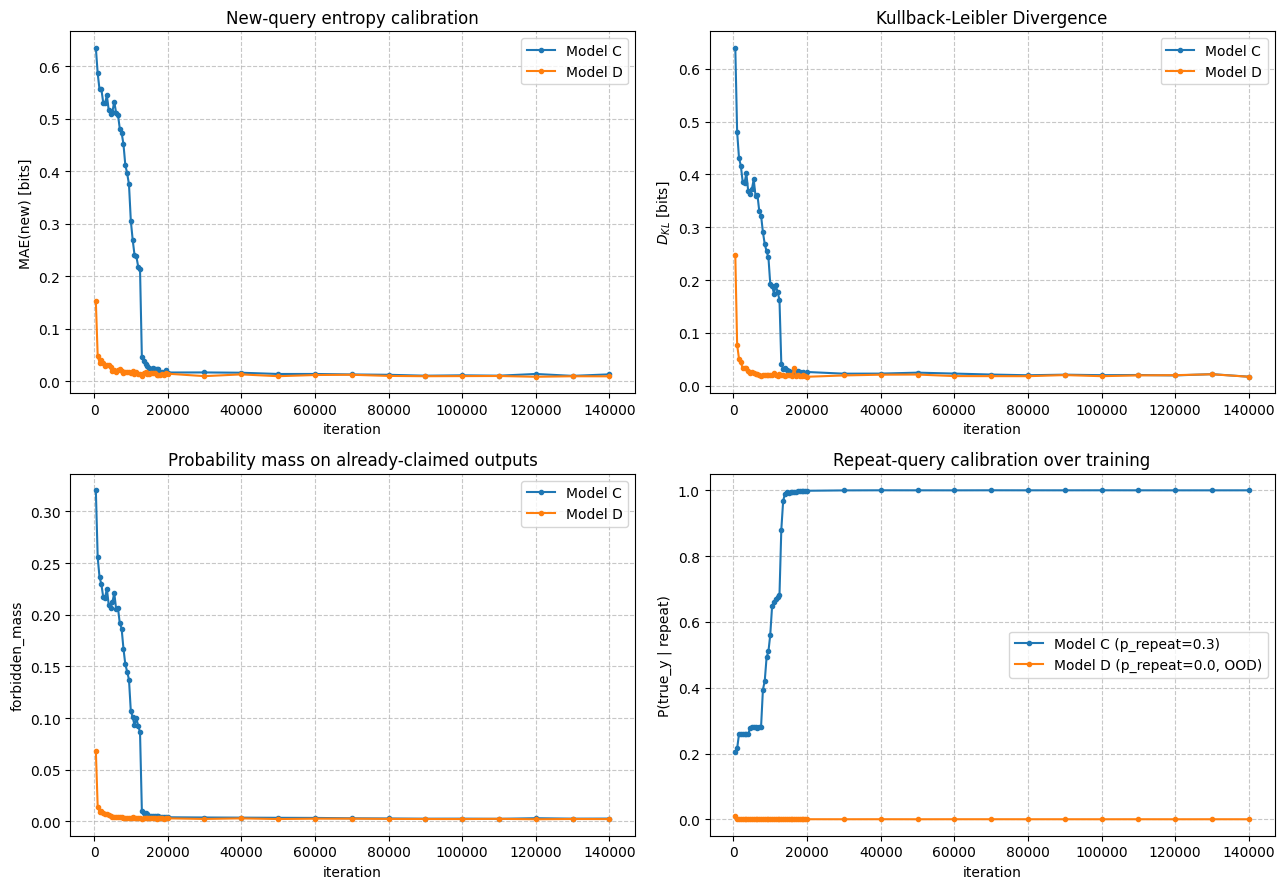

In [13]:
df_allCD = pd.read_csv('/kaggle/working/eval_sweep_combined_CD.csv')

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. New-query entropy calibration (MAE)
plot_metric_vs_iter(df_allCD, 'model_C_p03', 0.3, 'mae_new', axes[0, 0], 'Model C')
plot_metric_vs_iter(df_allCD, 'model_D_p00', 0.3, 'mae_new', axes[0, 0], 'Model D')
axes[0, 0].set_xlabel('iteration'); axes[0, 0].set_ylabel('MAE(new) [bits]')
axes[0, 0].set_title('New-query entropy calibration'); axes[0, 0].legend(); axes[0, 0].set_xscale('linear') 

# 2. Kullback-Leibler Divergence
plot_metric_vs_iter(df_allCD, 'model_C_p03', 0.3, 'mean_kl_new', axes[0, 1], 'Model C')
plot_metric_vs_iter(df_allCD, 'model_D_p00', 0.3, 'mean_kl_new', axes[0, 1], 'Model D')
axes[0, 1].set_xlabel('iteration'); axes[0, 1].set_ylabel('$D_{KL}$ [bits]') 
axes[0, 1].set_title('Kullback-Leibler Divergence'); axes[0, 1].legend(); axes[0, 1].set_xscale('linear')

# 3. Forbidden mass
plot_metric_vs_iter(df_allCD, 'model_C_p03', 0.3, 'mean_forbidden_mass', axes[1, 0], 'Model C')
plot_metric_vs_iter(df_allCD, 'model_D_p00', 0.3, 'mean_forbidden_mass', axes[1, 0], 'Model D')
axes[1, 0].set_xlabel('iteration'); axes[1, 0].set_ylabel('forbidden_mass')
axes[1, 0].set_title('Probability mass on already-claimed outputs'); axes[1, 0].legend(); axes[1, 0].set_xscale('linear')

# 4. Repeat-query calibration
plot_metric_vs_iter(df_allCD, 'model_C_p03', 0.3, 'mean_prob_true_y_repeat', axes[1, 1], 'Model C (p_repeat=0.3)')
plot_metric_vs_iter(df_allCD, 'model_D_p00', 0.3, 'mean_prob_true_y_repeat', axes[1, 1], 'Model D (p_repeat=0.0, OOD)')
axes[1, 1].set_xlabel('iteration'); axes[1, 1].set_ylabel('P(true_y | repeat)')
axes[1, 1].set_title('Repeat-query calibration over training'); axes[1, 1].legend(); axes[1, 1].set_xscale('linear')

for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_CD.png', dpi=150)
plt.show()

## Per-sequence entropy trajectories 

number of parameters: 2.68M


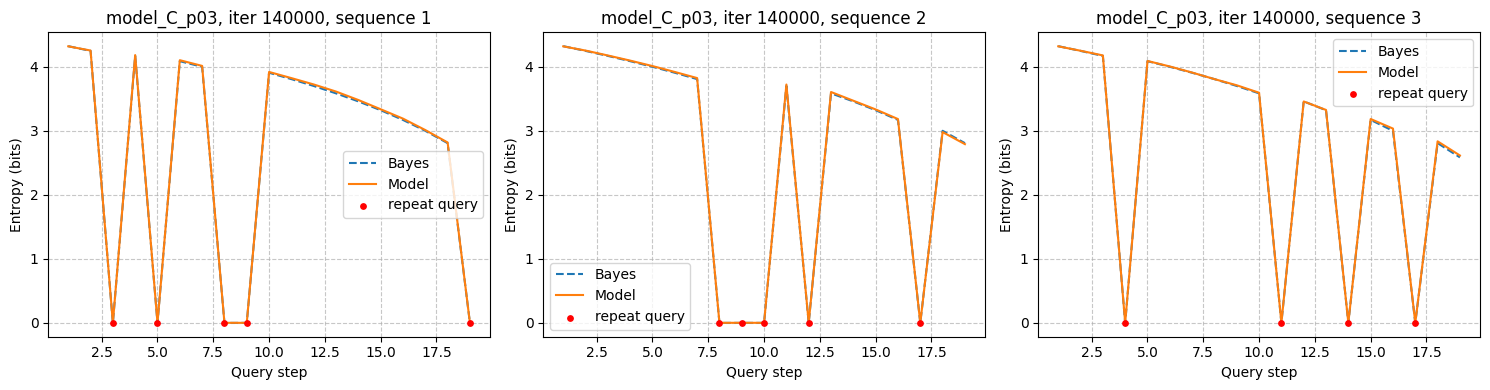

number of parameters: 2.68M


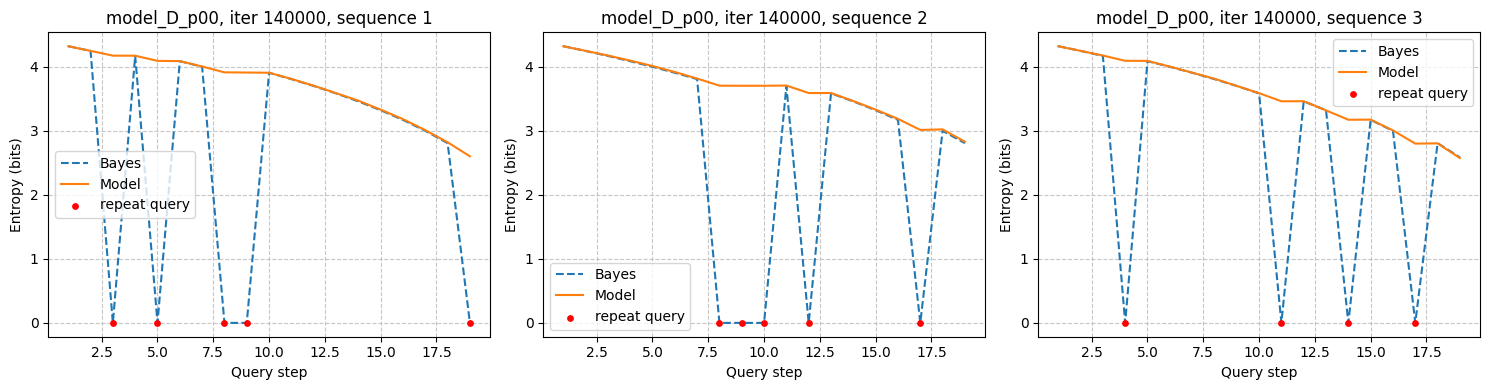

In [ ]:
@torch.no_grad()
def plot_staircases(model, V, K, device, p_repeat=0.3, n_examples=3, seed=99, title_prefix=''):
    """
    Generates and plots the entropy "staircase" for a set of random bijection sequences, 
    comparing the model's predicted entropy against the exact Bayesian posterior entropy.

    Args:
        model (torch.nn.Module): The trained Transformer model to evaluate.
        V (int): The vocabulary size.
        K (int): The query horizon (number of steps per sequence).
        device (str or torch.device): The device on which to perform computations.
        p_repeat (float, optional): Probability of repeating a previously queried input. Defaults to 0.3.
        n_examples (int, optional): Number of sequences to generate and plot (number of subplots). Defaults to 3.
        seed (int, optional): Random seed for reproducible sequence generation. Defaults to 99.
        title_prefix (str, optional): Prefix string to prepend to each subplot title. Defaults to ''.

    Returns:
        matplotlib.figure.Figure: The generated matplotlib figure containing the staircase plots.
    """
    model.eval()
    rng = random.Random(seed)
    fig, axes = plt.subplots(1, n_examples, figsize=(5 * n_examples, 4))
    if n_examples == 1:
        axes = [axes]
    for ax_i in range(n_examples):
        seq, meta = make_bijection_sequence(V, K, p_repeat, rng=rng)
        x = torch.tensor(seq[:-1], dtype=torch.long, device=device).unsqueeze(0)
        logits, _ = model(x)
        logits = logits[0]

        H_model, H_bayes, is_repeat = [], [], []
        for i, m in enumerate(meta):
            p_pos = 3 * i
            probs = F.softmax(logits[p_pos], dim=-1)[:V]  # softmax over the FULL vocab first, then drop SEP
            probs = probs / probs.sum()  # renormalize after dropping SEP mass
            H_model.append(float(-(probs * torch.log2(probs.clamp_min(1e-12))).sum().item()))
            H_bayes.append(0.0 if m['is_repeat'] else bayes_entropy_bits(V, m['n_used_before']))
            is_repeat.append(m['is_repeat'])

        steps = np.arange(1, K + 1)
        ax = axes[ax_i]
        ax.plot(steps, H_bayes, '--', label='Bayes')
        ax.plot(steps, H_model, '-', label='Model')
        repeat_steps = steps[np.array(is_repeat)]
        ax.scatter(repeat_steps, np.zeros_like(repeat_steps), color='red', s=15, zorder=5, label='repeat query')
        ax.set_title(f'{title_prefix}sequence {ax_i + 1}')
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlabel('Query step'); ax.set_ylabel('Entropy (bits)')
        ax.legend()
    plt.tight_layout()
    model.train()
    return fig

CKPT_ITER_FOR_STAIRCASE = 140000 # CHECKPOINT_SCHEDULE[-1]  # defaults to the last scheduled checkpoint

for run_name in ['model_C_p03', 'model_D_p00']:
    ckpt_path = os.path.join('/kaggle/working/checkpoints', f"{run_name}_iter{CKPT_ITER_FOR_STAIRCASE}.pt")
    
    if os.path.exists(ckpt_path):
        m, it, V_ck, K_ck, _ = load_model_from_checkpoint(ckpt_path, device)
        fig = plot_staircases(m, V_ck, K_ck, device, p_repeat=0.3, title_prefix=f'{run_name}, iter {it}, ')
        fig.savefig(f'/kaggle/working/staircase_{run_name}_iter{it}.png', dpi=150)
        plt.show()
        
        del m 
    else:
        print(f"[{run_name}] no checkpoint at iter {CKPT_ITER_FOR_STAIRCASE} yet")

## Geometric diagnostics: setup

This section implements the three geometric metrics used to characterize Bayesian calibration: **key orthogonality**, **QK sharpening across depth**, and **value-manifold unfurling**. We track these quantities across training checkpoints to determine if geometric shifts coincide with the behavioral phase transitions observed earlier.

To extract the required queries, keys, and block attention outputs, we register PyTorch forward hooks on minGPT's `CausalSelfAttention` submodules (`c_attn` for the concatenated Q/K/V projections and `c_proj` for the pre-residual attention output). *Note: These hook targets rely on minGPT's specific internal module naming conventions.*

In [ ]:
class AttentionCapture:
    """
    Captures queries (Q), keys (K), and pre-residual attention outputs across all model layers.

    This class registers PyTorch forward hooks on the `c_attn` and `c_proj` modules 
    of each Transformer block. 

    Usage:
        Call `.clear()` before initiating a forward pass to reset the storage. 
        After the forward pass, the captured tensors can be accessed via the 
        `.q`, `.k`, and `.attn_out` attributes, which are lists containing one 
        tensor per layer.
    """
    def __init__(self, model, n_head, n_embd):
        self.n_head = n_head
        self.n_embd = n_embd
        self.head_dim = n_embd // n_head
        self.q, self.k, self.attn_out = [], [], []
        self.handles = []
        for block in model.transformer.h:
            h1 = block.attn.c_attn.register_forward_hook(self._make_qk_hook())
            h2 = block.attn.c_proj.register_forward_hook(self._make_attnout_hook())
            self.handles += [h1, h2]

    def _make_qk_hook(self):
        def hook(module, inp, out):
            B, T, _ = out.shape
            q, k, v = out.split(self.n_embd, dim=2)
            q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)  # (B, nh, T, hd)
            k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
            self.q.append(q.detach())
            self.k.append(k.detach())
        return hook

    def _make_attnout_hook(self):
        def hook(module, inp, out):
            self.attn_out.append(out.detach())  # (B, T, n_embd) -- pre-residual, block attention output
        return hook

    def clear(self):
        self.q, self.k, self.attn_out = [], [], []

    def remove(self):
        for h in self.handles:
            h.remove()

## Diagnostic 1: Key Orthogonality Across All Layers

This diagnostic evaluates the pairwise cosine similarity of key vectors at every input-token position for each layer. The results are summarized using the **mean absolute off-diagonal cosine similarity**:

* **Values near 0:** Indicate near-orthogonal keys, representing a clean and distinct hypothesis basis.
* **Values near 1:** Indicate that the keys are collapsing onto each other.

We track this metric across all layers (0-5) to investigate whether key orthogonality is isolated to the initial layer or if this geometric property emerges deeper within the network.

In [ ]:
@torch.no_grad()
def measure_key_orthogonality(model, V, K, device, n_head, n_embd, n_seqs=20, seed=7):
    """
    Measures the orthogonality of key vectors across all Transformer layers.

    This function captures the key vectors at the query-input positions (x_k) 
    for a set of generated bijection sequences. It computes the pairwise 
    cosine similarity between these keys across all attention heads and calculates 
    the mean absolute off-diagonal similarity. 

    Args:
        model (torch.nn.Module): The model to evaluate.
        V (int): Vocabulary size.
        K (int): Query horizon (number of steps per sequence).
        device (str or torch.device): The device on which to perform computations.
        n_head (int): Number of attention heads.
        n_embd (int): Embedding dimension.
        n_seqs (int, optional): Number of held-out sequences to evaluate. Defaults to 20.
        seed (int, optional): Random seed for sequence generation. Defaults to 7.

    Returns:
        list[float]: A list of length `n_layer`, where each element represents the 
                     mean absolute off-diagonal cosine similarity of the key vectors 
                     for that specific layer. Values close to 0 indicate near-orthogonal keys.
    """
    capture = AttentionCapture(model, n_head, n_embd)
    rng = random.Random(seed)
    n_layer = len(model.transformer.h)
    per_layer_scores = [[] for _ in range(n_layer)]
    
    head_dim = n_embd // n_head

    for _ in range(n_seqs):
        seq, meta = make_bijection_sequence(V, K, p_repeat=0.3, rng=rng)
        x = torch.tensor(seq[:-1], dtype=torch.long, device=device).unsqueeze(0)
        capture.clear()
        model(x)

        query_positions = [3 * i for i in range(len(meta))]
        for layer in range(n_layer):
            k = capture.k[layer][0, :, query_positions, :]      # (H, N, d_head)
            k = k.permute(1, 0, 2).reshape(
                len(query_positions), n_head * head_dim
            )                                                   # (N, 192)
            k_norm = F.normalize(k, dim=-1)
            cos_sim = k_norm @ k_norm.T
            mask = ~torch.eye(len(query_positions), dtype=torch.bool, device=device)
            mean_abs_off_diag = cos_sim[mask].abs().mean().item()
            per_layer_scores[layer].append(mean_abs_off_diag)

    capture.remove()
    return [float(np.mean(scores)) for scores in per_layer_scores]

## Diagnostic 2: QK Sharpening Across Depth

This diagnostic evaluates how attention focus evolves from the shallowest layer to the deepest. By computing the cosine similarity (`cos(q_t, k_j)`) between queries and keys, it compares the diffuse attention typically found in Layer 0 against the highly concentrated attention expected in Layer 5.

Additionally, it tracks a scalar summary, which is the entropy of the row-normalized QK cosine similarity at query positions, across training checkpoints to determine if this sharpening effect emerges abruptly alongside the observed behavioral phase transitions.

In [ ]:
@torch.no_grad()
def qk_similarity_heatmap(model, V, K, device, n_head, n_embd, layer, seed=7):
    """
    Computes the pairwise cosine similarity between query and key vectors 
    for a single randomly generated sequence at a specific layer.

    Args:
        model (torch.nn.Module): The model to evaluate.
        V (int): Vocabulary size.
        K (int): Query horizon.
        device (str or torch.device): The device for computations.
        n_head (int): Number of attention heads.
        n_embd (int): Embedding dimension.
        layer (int): The specific layer index to analyze.
        seed (int, optional): Random seed. Defaults to 7.

    Returns:
        numpy.ndarray: A (T, T) matrix of cosine similarities averaged across all attention heads.
    """
    capture = AttentionCapture(model, n_head, n_embd)
    rng = random.Random(seed)
    seq, meta = make_bijection_sequence(V, K, p_repeat=0.3, rng=rng)
    x = torch.tensor(seq[:-1], dtype=torch.long, device=device).unsqueeze(0)
    capture.clear()
    model(x)

    q = capture.q[layer][0]  # (n_head, T, head_dim)
    k = capture.k[layer][0]
    q_norm = F.normalize(q, dim=-1)
    k_norm = F.normalize(k, dim=-1)
    cos_sim = torch.matmul(q_norm, k_norm.transpose(-2, -1)).mean(dim=0).cpu().numpy()  # avg over heads -> (T, T)

    capture.remove()
    return cos_sim


@torch.no_grad()
def measure_qk_sharpening(model, V, K, device, n_head, n_embd, layer, n_seqs=20, seed=7):
    """
    Calculates the mean entropy of the causal attention distribution at query positions.

    This function isolates the attention weights placed on valid hypothesis tokens ('x' tokens) 
    by applying causal and hypothesis masks. It returns the entropy of this filtered distribution 
    in nats, averaged over all attention heads, query positions, and sequences. 

    Args:
        model (torch.nn.Module): The model to evaluate.
        V (int): Vocabulary size.
        K (int): Query horizon.
        device (str or torch.device): The device for computations.
        n_head (int): Number of attention heads.
        n_embd (int): Embedding dimension.
        layer (int): The specific layer index to analyze.
        n_seqs (int, optional): Number of sequences to generate. Defaults to 20.
        seed (int, optional): Random seed. Defaults to 7.

    Returns:
        float: The mean entropy of the attention distribution. Lower values indicate sharper, 
               more concentrated attention.
    """
    capture = AttentionCapture(model, n_head, n_embd)
    rng = random.Random(seed)
    entropies = []
    
    head_dim = n_embd // n_head
    
    for _ in range(n_seqs):
        seq, meta = make_bijection_sequence(V, K, p_repeat=0.3, rng=rng)
        x = torch.tensor(seq[:-1], dtype=torch.long, device=device).unsqueeze(0)
        capture.clear()
        model(x)

        q = capture.q[layer][0]   # (H, T, head_dim)
        k = capture.k[layer][0]   # (H, T, head_dim)

        q_norm = F.normalize(q, dim=-1)
        k_norm = F.normalize(k, dim=-1)

        scores = torch.matmul(
            q_norm,
            k_norm.transpose(-2, -1)
        ) * math.sqrt(head_dim)
        # (H, T, T)

        # 1. Causal mask (prevents looking into the future)
        T = scores.shape[-1]
        causal = torch.tril(
            torch.ones(T, T, dtype=torch.bool, device=device)
        )
        scores = scores.masked_fill(~causal, float('-inf'))

        # 2. Hypothesis mask (forces attention only on 'x' tokens)
        # 'x' tokens are at indices 0, 3, 6, 9...
        x_positions = [3 * i for i in range((T + 2) // 3)]
        hypothesis_mask = torch.zeros(T, dtype=torch.bool, device=device)
        hypothesis_mask[x_positions] = True
        
        # Broadcast the mask to (H, T, T) and fill non-x columns with -inf
        scores = scores.masked_fill(~hypothesis_mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        # 3. Softmax
        attn = F.softmax(scores, dim=-1)

        # 4. Extract only the rows where the query itself is an 'x' token
        query_positions = [3 * i for i in range(len(meta))]
        attn_rows = attn[:, query_positions, :]

        # 5. Calculate Entropy 
        # (non-x positions will have prob 0, so they don't contribute due to clamp)
        entropy = -(attn_rows *
                    torch.log(attn_rows.clamp_min(1e-12))).sum(dim=-1)

        mean_entropy = entropy.mean().item()
        entropies.append(mean_entropy)

    capture.remove()
    return float(np.mean(entropies))

## Diagnostic 3: Value-Manifold Unfurling

This diagnostic applies Principal Component Analysis (PCA) to the final layer's block attention outputs at supervised prediction positions. Projecting these representations into 3D and coloring them by their exact Bayesian entropy reveals how the model's internal geometry evolves over time. We track this across early, mid, and late checkpoints to observe whether initially collapsed low-entropy states progressively "unfurl" into a smooth, entropy-ordered 1D curve.

In [ ]:
@torch.no_grad()
def collect_attn_output_manifold(model, V, K, device, n_head, n_embd, n_seqs=200, seed=7):
    """
    Collects the final layer's block attention outputs and their corresponding exact Bayesian entropies.

    This function processes a set of generated bijection sequences through the model, capturing the 
    pre-residual attention output at every supervised prediction position specifically from the deepest layer.

    Args:
        model (torch.nn.Module): The model to evaluate.
        V (int): Vocabulary size.
        K (int): Query horizon.
        device (str or torch.device): The device for computations.
        n_head (int): Number of attention heads.
        n_embd (int): Embedding dimension.
        n_seqs (int, optional): Number of sequences to generate and process. Defaults to 200.
        seed (int, optional): Random seed. Defaults to 7.

    Returns:
        tuple: A tuple containing:
            - X (numpy.ndarray): An (n_points, n_embd) array representing the pooled last-layer attention outputs.
            - ents (numpy.ndarray): An (n_points,) array of matching analytic Bayes entropies 
              (0.0 for repeats, log2(V-n_used) for novel queries).
    """
    capture = AttentionCapture(model, n_head, n_embd)
    rng = random.Random(seed)
    n_layer = len(model.transformer.h)
    xs, ents = [], []

    for _ in range(n_seqs):
        seq, meta = make_bijection_sequence(V, K, p_repeat=0.3, rng=rng)
        x = torch.tensor(seq[:-1], dtype=torch.long, device=device).unsqueeze(0)
        capture.clear()
        model(x)

        last_layer_out = capture.attn_out[n_layer - 1][0]  # (T, n_embd)
        for i, m in enumerate(meta):
            p_pos = 3 * i
            xs.append(last_layer_out[p_pos].cpu().numpy())
            ents.append(0.0 if m['is_repeat'] else bayes_entropy_bits(V, m['n_used_before']))

    capture.remove()
    return np.stack(xs), np.array(ents)


def plot_value_manifold(model, V, K, device, n_head, n_embd, ax, title='', n_seqs=200):
    """
    Projects the final layer's block attention outputs into 3D space using PCA and plots the manifold.

    The resulting scatter plot colors each projected point according to its exact Bayesian entropy, 
    visually illustrating how the model's internal representations are structured and whether they 
    unfurl based on certainty.

    Args:
        model (torch.nn.Module): The model to evaluate.
        V (int): Vocabulary size.
        K (int): Query horizon.
        device (str or torch.device): The device for computations.
        n_head (int): Number of attention heads.
        n_embd (int): Embedding dimension.
        ax (matplotlib.axes._subplots.Axes3DSubplot): The 3D matplotlib axis to plot on.
        title (str, optional): The title for the subplot. Defaults to ''.
        n_seqs (int, optional): Number of sequences to generate for the PCA projection. Defaults to 200.

    Returns:
        matplotlib.collections.PathCollection: The matplotlib scatter object, which can be used to add a colorbar.
    """
    from sklearn.decomposition import PCA

    X, ents = collect_attn_output_manifold(model, V, K, device, n_head, n_embd, n_seqs=n_seqs)

    pca = PCA(n_components=3)
    X3 = pca.fit_transform(X)

    sc = ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c=ents, cmap='viridis', s=8)

    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')

    return sc

## Tracking diagnostics 1 & 2 over training

Runs key orthogonality and QK sharpening across every saved checkpoint and every layer.

In [ ]:
N_HEAD, N_EMBD = 6, 192

def track_geometry_over_checkpoints(checkpoint_dir, run_name, device):
    """
    Tracks geometric diagnostics across all saved model checkpoints for a specific run.

    This function sequentially loads checkpoints and computes structural metrics:
    key orthogonality (specifically for Layer 0) and QK sharpening (across all layers). 
    Tracking these quantities over training iterations allows us to observe if 
    internal geometric shifts align with the model's behavioral phase transitions.

    Args:
        checkpoint_dir (str): The directory containing the saved checkpoints.
        run_name (str): The specific prefix/identifier for the training run.
        device (str or torch.device): The device for computations.

    Returns:
        pandas.DataFrame: A DataFrame containing the tracked geometric metrics 
                          ('key_orth_layer0' and 'sharp_layerX') indexed by iteration.
    """
    rows = []
    ckpts = sorted(
        glob.glob(os.path.join(checkpoint_dir, f"{run_name}_iter*.pt")),
        key=lambda p: int(p.split('iter')[-1].replace('.pt', ''))
    )
    
    for ckpt_path in ckpts:
        model, iter_num, V_ck, K_ck, _ = load_model_from_checkpoint(ckpt_path, device)
        n_layers = len(model.transformer.h)
        
        row = {'run_name': run_name, 'iter': iter_num}
        
        # 1. Key Orthogonality (Extracting only Layer 0)
        key_orth_all = measure_key_orthogonality(model, V_ck, K_ck, device, N_HEAD, N_EMBD)
        row['key_orth_layer0'] = key_orth_all[0]
        
        # 2. QK Sharpening (Looping over all layers dynamically)
        for layer_idx in range(n_layers):
            sharp_score = measure_qk_sharpening(model, V_ck, K_ck, device, N_HEAD, N_EMBD, layer=layer_idx)
            row[f'sharp_layer{layer_idx}'] = sharp_score
        
        print(f"[{run_name}] geometry @ iter {iter_num}: "
              f"key_orth(L0)={row['key_orth_layer0']:.3f} "
              f"sharp(L0)={row['sharp_layer0']:.3f} "
              f"sharp(L4)={row['sharp_layer4']:.3f}")
        
        rows.append(row)
        
        del model
        torch.cuda.empty_cache()
        
    return pd.DataFrame(rows)

geom_C = track_geometry_over_checkpoints('/kaggle/working/checkpoints', 'model_C_p03', device)
geom_D = track_geometry_over_checkpoints('/kaggle/working/checkpoints', 'model_D_p00', device)

geom_all_CD = pd.concat([geom_C, geom_D], ignore_index=True)
geom_all_CD.to_csv('/kaggle/working/geometry_over_training_CD.csv', index=False)

number of parameters: 2.68M
[model_C_p03] geometry @ iter 500: key_orth(L0)=0.270 sharp(L0)=1.160 sharp(L4)=1.699
number of parameters: 2.68M
[model_C_p03] geometry @ iter 1000: key_orth(L0)=0.320 sharp(L0)=1.168 sharp(L4)=1.627
number of parameters: 2.68M
[model_C_p03] geometry @ iter 1500: key_orth(L0)=0.361 sharp(L0)=1.114 sharp(L4)=1.665
number of parameters: 2.68M
[model_C_p03] geometry @ iter 2000: key_orth(L0)=0.356 sharp(L0)=1.175 sharp(L4)=1.532
number of parameters: 2.68M
[model_C_p03] geometry @ iter 2500: key_orth(L0)=0.369 sharp(L0)=1.286 sharp(L4)=1.575
number of parameters: 2.68M
[model_C_p03] geometry @ iter 3000: key_orth(L0)=0.368 sharp(L0)=1.364 sharp(L4)=1.586
number of parameters: 2.68M
[model_C_p03] geometry @ iter 3500: key_orth(L0)=0.373 sharp(L0)=1.316 sharp(L4)=1.694
number of parameters: 2.68M
[model_C_p03] geometry @ iter 4000: key_orth(L0)=0.410 sharp(L0)=1.373 sharp(L4)=1.656
number of parameters: 2.68M
[model_C_p03] geometry @ iter 4500: key_orth(L0)=0.45

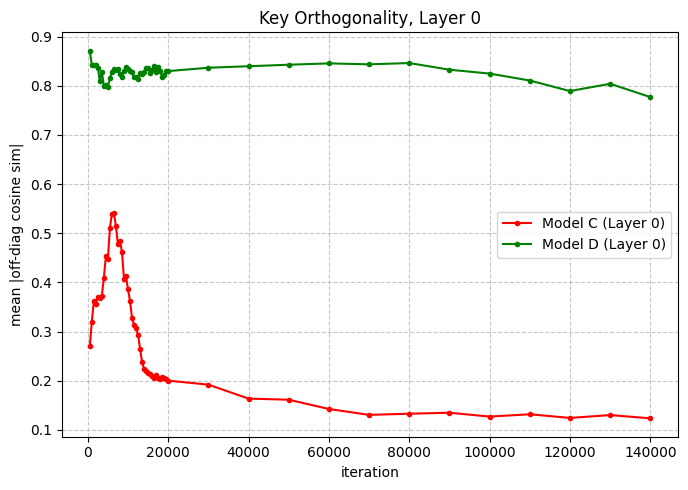

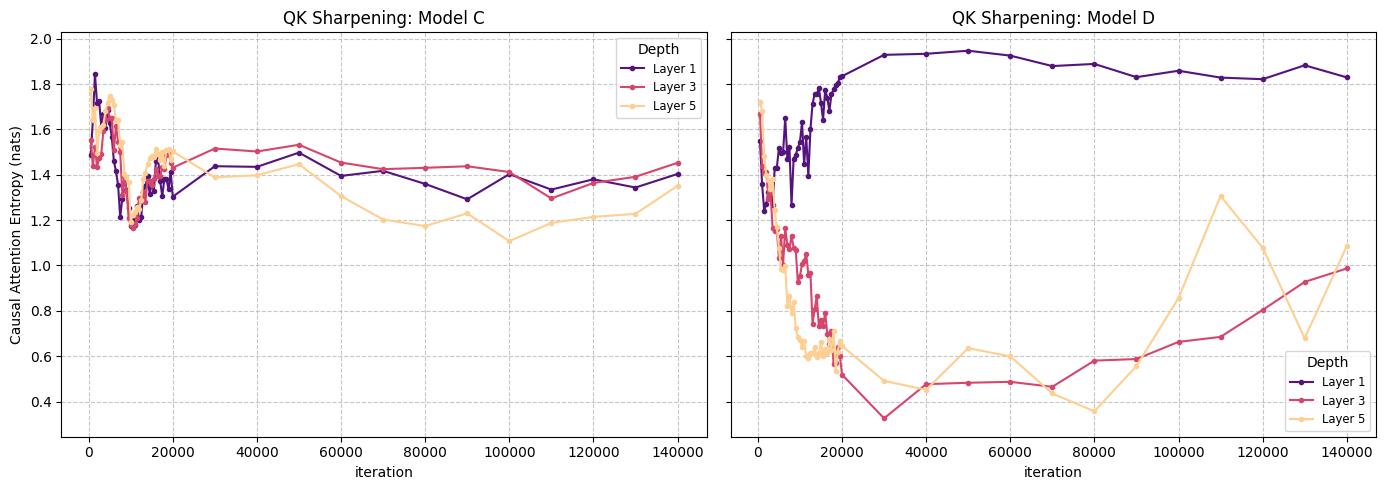

In [20]:
import matplotlib.cm as cm

geom_all = pd.read_csv('/kaggle/working/geometry_over_training_CD.csv')

plt.figure(figsize=(7, 5))

colors_ = ['red', 'green']

for idx, pack in enumerate([('model_C_p03', 'Model C'), ('model_D_p00', 'Model D')]):
    run_name, label = pack
    sub = geom_all[geom_all.run_name == run_name].sort_values('iter')
    plt.plot(sub['iter'], sub['key_orth_layer0'], marker='o', markersize=3, label=f'{label} (Layer 0)', color=colors_[idx])

plt.xlabel('iteration')
plt.ylabel('mean |off-diag cosine sim|')
plt.title('Key Orthogonality, Layer 0')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/key_orthogonality_plot_CD.png', dpi=150)
plt.show()

sharp_cols = [c for c in geom_all.columns if c.startswith('sharp_layer')]
n_layers = len(sharp_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

models = [
    ('model_C_p03', 'Model C', axes[0]), 
    ('model_D_p00', 'Model D', axes[1])
]

colors = cm.magma(np.linspace(0.1, 0.9, n_layers))

for run_name, label, ax in models:
    sub = geom_all[geom_all.run_name == run_name].sort_values('iter')
    
    for i in [1,3,5]:
        ax.plot(sub['iter'], sub[f'sharp_layer{i}'], marker='o', markersize=3, 
                color=colors[i], label=f'Layer {i}')
        
    ax.set_xlabel('iteration')
    ax.set_title(f'QK Sharpening: {label}')
    ax.legend(title="Depth", fontsize='small')
    ax.grid(True, linestyle='--', alpha=0.7)

axes[0].set_ylabel('Causal Attention Entropy (nats)')

plt.tight_layout()
plt.savefig('/kaggle/working/qk_sharpening_all_layers_CD.png', dpi=150)
plt.show()

## Value manifold: early vs transition/mid vs late

number of parameters: 2.68M
number of parameters: 2.68M
number of parameters: 2.68M
number of parameters: 2.68M
number of parameters: 2.68M
number of parameters: 2.68M


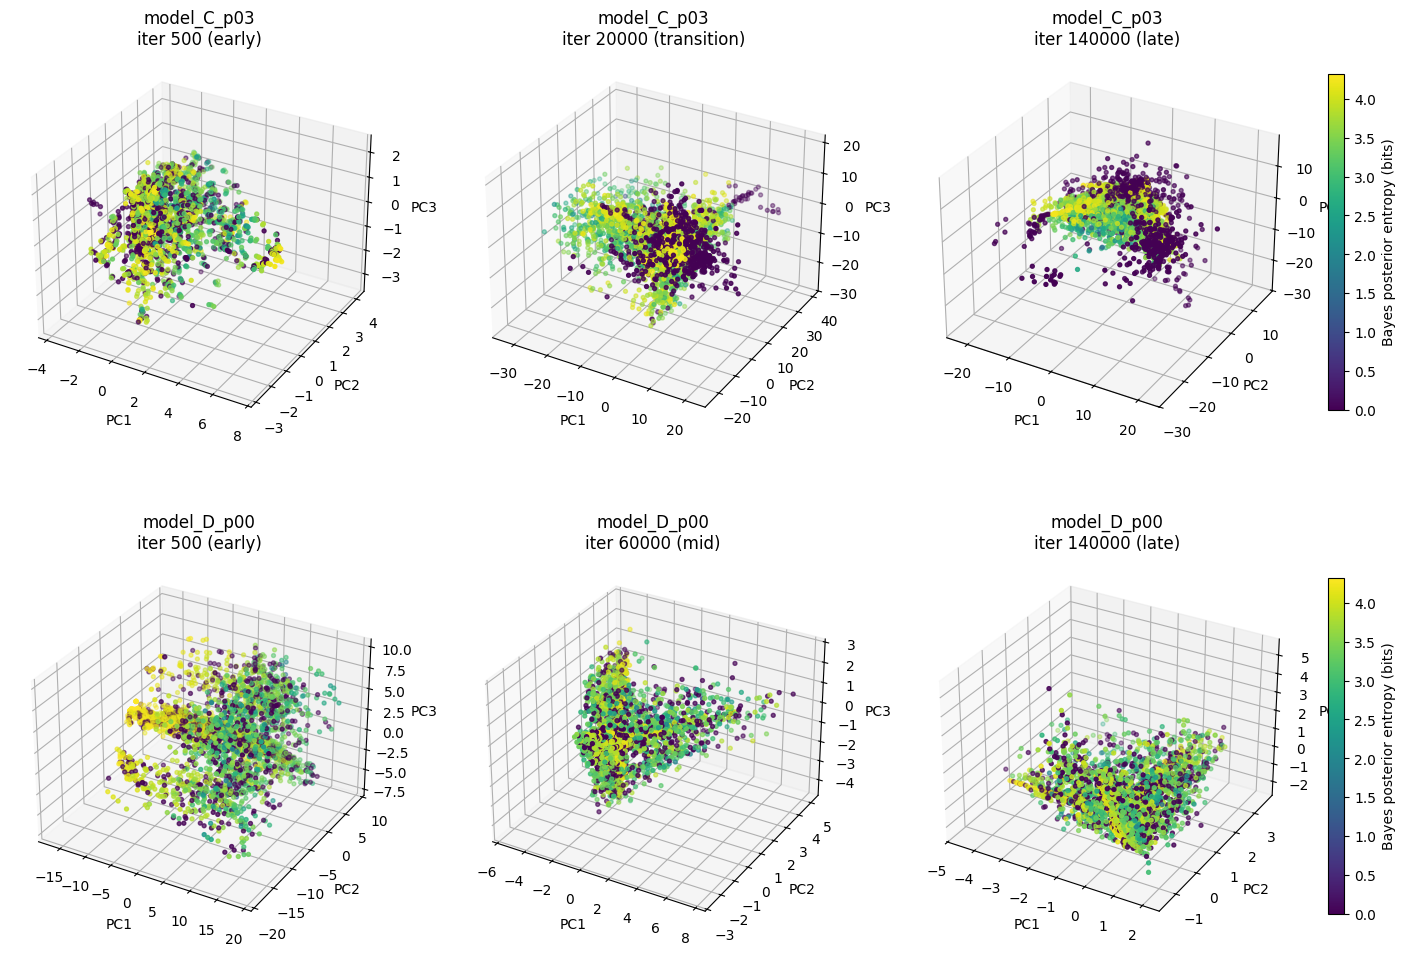

In [21]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

run_configs = [
    ('model_C_p03', [('early', 500), ('transition', 20000), ('late', 140000)]),
    ('model_D_p00', [('early', 500), ('mid', 60000), ('late', 140000)])
]

fig = plt.figure(figsize=(20, 12))

plot_idx = 1
for run_name, checkpoints in run_configs:
    row_axes = []
    last_sc = None
    
    for tag, it in checkpoints:
        ax = fig.add_subplot(2, 3, plot_idx, projection='3d')
        row_axes.append(ax)
        plot_idx += 1
        
        ckpt_path = os.path.join('/kaggle/working/checkpoints', f"{run_name}_iter{it}.pt")
        if not os.path.exists(ckpt_path):
            print(f"[{run_name}] no checkpoint at iter {it}, skipping")
            continue
            
        model, iter_num, V_ck, K_ck, _ = load_model_from_checkpoint(ckpt_path, device)
        
        last_sc = plot_value_manifold(model, V_ck, K_ck, device, N_HEAD, N_EMBD, ax, 
                                      title=f'{run_name}\niter {iter_num} ({tag})')
        
        del model
        
    if last_sc is not None:
        cbar = fig.colorbar(last_sc, ax=row_axes, shrink=0.8, pad=0.02)
        cbar.set_label('Bayes posterior entropy (bits)')

fig.savefig('/kaggle/working/manifold_3d_grid_CD.png', dpi=150)
plt.show()